### IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import os 
import tqdm
import glob
import tensorflow 
import random

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers

from keras.callbacks import Callback,ModelCheckpoint
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout
from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K

#import tensorflow_addons as tfa
#from tensorflow.keras.metrics import Metric
#from tensorflow_addons.utils.types import AcceptableDTypes, FloatTensorLike
from typeguard import typechecked
from typing import Optional
import tensorflow 

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import keras.backend as K

2025-03-24 20:49:09.904798: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-24 20:49:10.045603: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-24 20:49:10.087466: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-24 20:49:10.755918: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

In [2]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
filepath = '../models/mobilenet_original_augmented.h5'
datapath = "../original_augmented/"
batch_size = 128

In [3]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   validation_split = 0.2,
                                  
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        #zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

valid_datagen = ImageDataGenerator(rescale = 1./255,
                                  validation_split = 0.2)

test_datagen  = ImageDataGenerator(rescale = 1./255
                                  )

In [4]:
train_dataset  = train_datagen.flow_from_directory(directory = datapath + 'train',
                                                   target_size = (224,224),
                                                   class_mode = 'categorical',
                                                   subset = 'training',
                                                   batch_size = 128)

Found 13156 images belonging to 3 classes.


In [5]:
valid_dataset  = train_datagen.flow_from_directory(directory = datapath + 'train',
                                                   target_size = (224,224),
                                                   class_mode = 'categorical',
                                                   subset = 'validation',
                                                   batch_size = 128)

Found 3287 images belonging to 3 classes.


## feature preprocessing and label encoding.

### MODEL BUILDING

In [6]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), 
                   include_top=False,
                   weights="imagenet")

2025-03-24 20:49:20.993006: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-24 20:49:21.130930: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20750 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:00:03.0, compute capability: 8.9


In [7]:
# Freezing Layers

for layer in base_model.layers:
    layer.trainable=False

In [8]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(3,activation='softmax'))

In [9]:
# Model Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 dropout (Dropout)           (None, 7, 7, 1280)        0         
                                                                 
 flatten (Flatten)           (None, 62720)             0         
                                                                 
 batch_normalization (BatchN  (None, 62720)            250880    
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 32)                2007072   
                                                                 
 batch_normalization_1 (Batc  (None, 32)               1

In [10]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [11]:
OPT    = tensorflow.keras.optimizers.Adam(lr=0.001)
METRICS = [
      tensorflow.keras.metrics.AUC(name = 'auc'),
      tensorflow.keras.metrics.CategoricalAccuracy(name='accuracy'),
      tensorflow.keras.metrics.Precision(name='precision'),
      tensorflow.keras.metrics.Recall(name='recall'),  
        f1_score,
          ]
model.compile(loss='categorical_crossentropy',
              metrics=METRICS,
              optimizer=OPT)

/opt/conda/envs/mlp/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [12]:
# Defining Callbacks
earlystopping = EarlyStopping(monitor = 'val_auc', 
                              mode = 'max' , 
                              patience = 15,
                              verbose = 1)

checkpoint    = ModelCheckpoint(filepath, 
                                monitor = 'val_auc', 
                                mode='max', 
                                save_best_only=True, 
                                save_weights_only=False,
                                verbose = 1)


callback_list = [earlystopping, checkpoint]

In [13]:
model_history=model.fit(train_dataset,
                        validation_data=valid_dataset,
                        epochs = 100,
                        callbacks = callback_list,
                        verbose = 1)

Epoch 1/100
  1/103 [..............................] - ETA: 9:16 - loss: 1.4128 - auc: 0.4662 - accuracy: 0.3047 - precision: 0.2889 - recall: 0.2031 - f1_score: 0.2385

2025-03-24 20:49:34.503233: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8900
2025-03-24 20:49:34.580685: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


103/103 [==============================] - ETA: 0s - loss: 1.1312 - auc: 0.5861 - accuracy: 0.4066 - precision: 0.4496 - recall: 0.1904 - f1_score: 0.2670
Epoch 1: val_auc improved from -inf to 0.71332, saving model to ../models/mobilenet_original_augmented.h5
103/103 [==============================] - 194s 2s/step - loss: 1.1312 - auc: 0.5861 - accuracy: 0.4066 - precision: 0.4496 - recall: 0.1904 - f1_score: 0.2670 - val_loss: 1.0477 - val_auc: 0.7133 - val_accuracy: 0.5936 - val_precision: 0.5773 - val_recall: 0.4728 - val_f1_score: 0.5180
Epoch 2/100
103/103 [==============================] - ETA: 0s - loss: 1.0198 - auc: 0.6617 - accuracy: 0.4709 - precision: 0.5921 - recall: 0.2180 - f1_score: 0.3181
Epoch 2: val_auc improved from 0.71332 to 0.74996, saving model to ../models/mobilenet_original_augmented.h5
103/103 [==============================] - 179s 2s/step - loss: 1.0198 - auc: 0.6617 - accuracy: 0.4709 - precision: 0.5921 - recall: 0.2180 - f1_score: 0.3181 - val_loss: 0.9

Epoch 80/100
75/75 [==============================] - ETA: 0s - loss: 0.5912 - auc: 0.9046 - accuracy: 0.7503 - precision: 0.7816 - recall: 0.7001 - f1_score: 0.7383
Epoch 80: val_auc did not improve from 0.85884
75/75 [==============================] - 104s 1s/step - loss: 0.5912 - auc: 0.9046 - accuracy: 0.7503 - precision: 0.7816 - recall: 0.7001 - f1_score: 0.7383 - val_loss: 0.7569 - val_auc: 0.8529 - val_accuracy: 0.6870 - val_precision: 0.7112 - val_recall: 0.6559 - val_f1_score: 0.6830
Epoch 81/100
75/75 [==============================] - ETA: 0s - loss: 0.5848 - auc: 0.9066 - accuracy: 0.7534 - precision: 0.7845 - recall: 0.7073 - f1_score: 0.7432
Epoch 81: val_auc improved from 0.85884 to 0.86021, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 104s 1s/step - loss: 0.5848 - auc: 0.9066 - accuracy: 0.7534 - precision: 0.7845 - recall: 0.7073 - f1_score: 0.7432 - val_loss: 0.7295 - val_auc: 0.8602 - val_accuracy: 0.6971 - val_preci

Epoch 96/100
75/75 [==============================] - ETA: 0s - loss: 0.5705 - auc: 0.9116 - accuracy: 0.7564 - precision: 0.7907 - recall: 0.7123 - f1_score: 0.7496
Epoch 96: val_auc improved from 0.86402 to 0.86749, saving model to ../models/saved/best_weights_mos.hdf5
75/75 [==============================] - 105s 1s/step - loss: 0.5705 - auc: 0.9116 - accuracy: 0.7564 - precision: 0.7907 - recall: 0.7123 - f1_score: 0.7496 - val_loss: 0.7108 - val_auc: 0.8675 - val_accuracy: 0.7122 - val_precision: 0.7343 - val_recall: 0.6794 - val_f1_score: 0.7047
Epoch 97/100
75/75 [==============================] - ETA: 0s - loss: 0.5664 - auc: 0.9130 - accuracy: 0.7652 - precision: 0.7955 - recall: 0.7215 - f1_score: 0.7563
Epoch 97: val_auc did not improve from 0.86749
75/75 [==============================] - 103s 1s/step - loss: 0.5664 - auc: 0.9130 - accuracy: 0.7652 - precision: 0.7955 - recall: 0.7215 - f1_score: 0.7563 - val_loss: 0.7139 - val_auc: 0.8654 - val_accuracy: 0.7088 - val_preci

In [ ]:
from tensorflow.keras.utils import to_categorical, plot_model
#plot_model(model, to_file='NN-mnist.png', show_shapes=True)

In [ ]:
#model.load_weights("/kaggle/input/zahaimar-22/zahaimar_v2.h5")

In [ ]:
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=METRICS)

In [14]:
#test_dataset = tf.keras.preprocessing.image_dataset_from_directory("../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test",
##                                                            shuffle=False,
#                                                            image_size=(224,224),
#                                                            batch_size=32,
#)

best_model = tf.keras.models.load_model('../models/mobilenet_template.h5', custom_objects={"f1_score": f1_score})

test_dataset = valid_datagen.flow_from_directory(directory = datapath + "test",
                                                  target_size = (224,224),
                                                  class_mode = 'categorical'
                                                  )

Found 2839 images belonging to 3 classes.


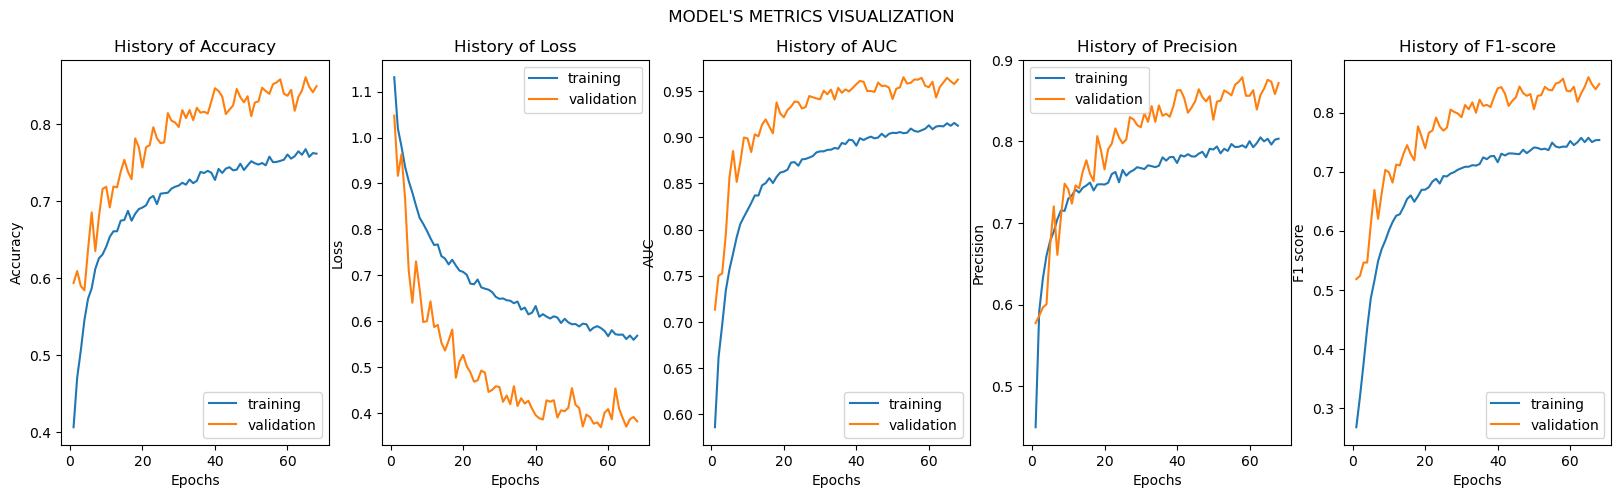

In [15]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (20,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(model_history.history['accuracy'],model_history.history['val_accuracy'],
               model_history.history['loss'],model_history.history['val_loss'],
               model_history.history['auc'],model_history.history['val_auc'],
               model_history.history['precision'],model_history.history['val_precision'],
               model_history.history['f1_score'],model_history.history['val_f1_score']
              )

In [16]:
scores = best_model.evaluate(test_dataset)

89/89 [==============================] - 5s 40ms/step - loss: 1.3990 - auc: 0.6189 - accuracy: 0.5129 - precision: 0.5095 - recall: 0.4921 - f1_score: 0.5009


In [17]:
print(scores)
# print("Accuracy = ", scores[1])
# print("Precision = ", scores[2])
# print("Recall = ", scores[3])
# print("AUC = ", scores[4])
# print("F1_score = ", scores[5])

[1.3990148305892944, 0.6188662052154541, 0.512856662273407, 0.5094821453094482, 0.4920746684074402, 0.5008818507194519]


# Test on the DataSet

Loaded ../original_augmented/test/AD/I47186_110.png
1/1 [==============================] - 0s 27ms/step
59.95 % chances are there that the image is AD


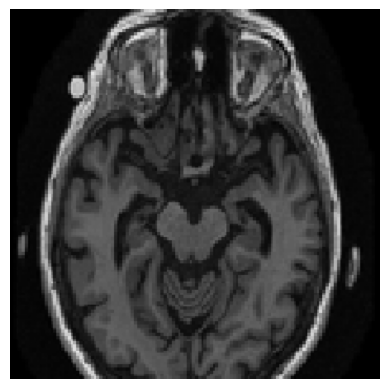

In [18]:
# Test Case 1: Alzheimers

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

cog_dir = os.path.join(datapath + "test", random.choice(os.listdir(datapath + "test")))
img_dir = os.path.join(cog_dir, random.choice(os.listdir(cog_dir)))
print(f"Loaded {img_dir}")

img = load_img(img_dir, target_size = (224,224,3))
img = img_to_array(img)
img = img/255
plt.imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

class_index = np.argmax(model.predict(img),axis=1)[0]

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', idc[class_index])

# Confusion Matrix

In [19]:
true_classes = test_dataset.classes
class_indices = test_dataset.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

preds = model.predict(test_dataset)
pred_classes = np.argmax(preds, axis=1)

89/89 [==============================] - 4s 41ms/step


In [20]:
print(train_dataset.class_indices.keys())

dict_keys(['AD', 'CN', 'MCI'])


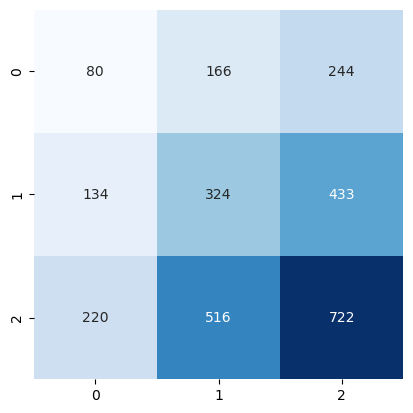

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the ten classes
class_names = test_dataset.class_indices.keys()

def plot_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
    )

plt.figure()
plot_heatmap(true_classes, pred_classes)    

plt.show()

# 